In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Defining the Hardware for training and inference

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


#  Data Loading and Pre-Processing

In [21]:
transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307), (0.3081))
])

In [22]:
train_images = torchvision.datasets.MNIST(root='./data', train=True, transform=transforms, download=True)
test_images = torchvision.datasets.MNIST(root='./data', train=False, transform=transforms, download=True)

In [23]:
train_data = DataLoader(train_images, batch_size=64, shuffle=True)
test_data = DataLoader(test_images, batch_size=64, shuffle=False)

# Model building

In [24]:
class MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(784, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.layers(x)
        return x

# Initialize model, loss function and Optimizer

In [45]:
model = MNIST()

loss_function = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [44]:
def train(model, data, optimizer, loss_function, device):
    model = model.to(device)

    model.train()

    for image, label in data:
        image, label = image.to(device), label.to(device)
        optimizer.zero_grad()

        output = model(image)
        loss = loss_function(output, label)
        loss.backward()
        optimizer.step()
        
    return model, loss.item()


# Inference

In [69]:
def predict(model, data):

    model.eval()
    
    with torch.no_grad():
        output = model(data)
        print(f"output shape: {output.shape}")
        _, index = output.max(1)
        print(f"model's output = {output}")
        print(f"model's prediction {index.item()}")
        
        

# Training Loop

In [34]:
num_epoch = 5

In [63]:
for epoch in range(num_epoch):

    model, loss = train(model, train_data, optimizer, loss_function, device)
    print(loss)

0.03532565012574196
0.029026608914136887
0.00747420359402895
0.027930349111557007
0.041550252586603165


actual image = 0
output shape: torch.Size([1, 10])
model's output = tensor([[ 20.8342, -30.9261,  -7.4803, -19.0237,  -6.8091,  -7.8469,   3.8244,
         -10.5364,  -3.6718,   3.5592]])
model's prediction 0


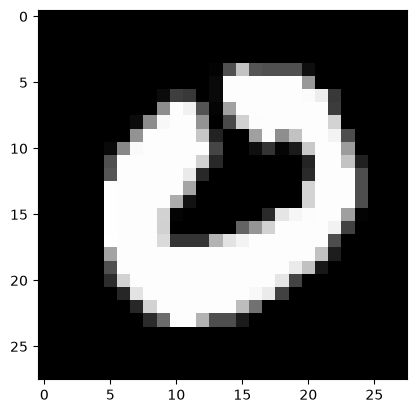

In [72]:
label_idx = 25


for image, label in test_data:
    plt.imshow(image[label_idx].squeeze(0), cmap='gray')
    print(f"actual image = {label[label_idx]}")
    predict(model, image[label_idx])
    break